# Xenium Transcriptomics → Spatial ATAC-seq Alignment

**Objective**: Align Xenium transcriptomics cells to spatial ATAC-seq spots using multimodal registration.

**Pipeline**:
1. Load ATAC & Xenium objects from h5ad
2. Normalize and compute PCA
3. Affine alignment (translation, rotation, scale)
4. Rasterize cells into pixel grids (400×400×50)
5. Nonlinear alignment via neural network (learns smooth deformation field)
6. Save warped coordinates and visualizations
7. Map Xenium cells to ATAC spots using point-in-polygon method

**Outputs**:
- Warped coordinates in `.obsm["spatial_warped"]` and `.obs` columns
- Xenium-to-ATAC mapping with density statistics
- Visualization plots (alignment overlays, deformation fields)
- CSV files with mapping results

**Dependencies**: scanpy, torch, MOSAICField, shapely

---



## Step 0: Setup & Import Libraries

Import all required packages and MOSAICField modules.


In [1]:
import os
print(os.environ.get('CONDA_DEFAULT_ENV'))
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import torch
import sys

/projectnb/paxlab/presh/env/conda_env/mosaicfield_env


In [3]:
sys.path.append(os.path.abspath("/projectnb/paxlab/presh/software/MOSAICField/src/MOSAICField"))
sys.path.append(os.path.abspath("/projectnb/paxlab/presh/software/MOSAICField"))
from src.MOSAICField.affine_alignment import affine_align
from src.MOSAICField.nonlinear_alignment import warp_image, warp_image_reverse, nonlinear_align

## Step 0b: Define Helper Functions for Visualization

Utility functions for plotting aligned tissues and computing statistics.


In [ ]:
"""
Visualize the mouse embryo slice given cell coordinates
"""
def visualize_slice(adata, coords, annotation_key="cluster"):
    ann = adata.obs[annotation_key]  # categorical
    cats = list(ann.cat.categories)
    
    # Build the expected color key, e.g. cluster -> cluster_colors
    color_key = f"{annotation_key}_colors"
    if color_key not in adata.uns:
        raise ValueError(f"{color_key} not found in adata.uns. Available keys: {list(adata.uns.keys())}")
    palette = list(adata.uns[color_key])  # must align with `cats`
    
    # Map category -> color
    cat2color = dict(zip(cats, palette))
    
    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    for cat in cats:
        mask = (ann == cat).values
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=5,
            linewidths=0,
            c=cat2color[cat],
            label=cat
        )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    # plt.savefig("spatial.png", bbox_inches="tight", dpi=300)

In [ ]:
"""
Plotting overlapping slices for the purpose of visualizing their aligned coordinates
"""
def plot_slices_overlap(slices, colors=['#1f77b4','#ff7f0e'], invert_axis=True, s=1, save_path=None):
    plt.figure()
    for i in range(len(slices)):
        plt.scatter(slices[i][:,0],slices[i][:,1],marker=".", s=s, color=colors[i])
    if invert_axis:
        plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal', adjustable='box')  # preserve aspect ratio
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

# Step 1: Load & Prepare ATAC Data

Load Arrow file, create AnnData object, and prepare for alignment.

In [ ]:
atac =  sc.read_h5ad('/projectnb/paxlab/DATA/DriesSpatial/Atlasxomics/D1942/D1942_deepseq/ultima1942optimize/set1_vf25000-cr1-0-vi1-nc30/combined.h5ad')
# atac.X = atac.layers['count']
# del atac.layers['count']

In [ ]:
print(atac)

In [ ]:
import matplotlib.pyplot as plt

def add_colors_to_obs(adata, annotation_key, palette=None):
    ann = adata.obs[annotation_key]
    cats = list(ann.cat.categories)
    if palette is None:
        # Pick a palette: use matplotlib/tab20, tab10, or set3
        # Use as many colors as needed for your number of categories
        cmap = plt.get_cmap('tab20')
        palette = [cmap(i % cmap.N) for i in range(len(cats))]
    adata.uns[f"{annotation_key}_colors"] = palette
    return palette

# Example: For "cluster"
add_colors_to_obs(atac, "cluster")

coords = np.asarray(atac.obsm["spatial"], dtype=float)
visualize_slice(atac, coords, annotation_key="cluster")

# Step 2: Load & Prepare Xenium Data

In [ ]:
import scanpy as sc
import pandas as pd
from scipy import io
from scipy import sparse

# ----- 1. Load your files -----
# Edit these paths if your output directory is different
expr_path = "/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_expr.mtx"
genes_path = "/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_genes.csv"
cells_path = "/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_cells.csv"
cellmeta_path = "/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_cell_coords.csv"

# ----- 2. Read expression matrix -----
X = io.mmread(expr_path)  # genes x cells in Matrix Market format (should be sparse!)
X = sparse.csc_matrix(X)  # ensure it's the right sparse format

# ----- 3. Read row (gene) and column (cell) metadata -----
gene_names = pd.read_csv(genes_path).iloc[:,0].values     # Should match order of X rows
cell_names = pd.read_csv(cells_path).iloc[:,0].values     # Should match order of X cols

# ----- 4. Read cell meta/coords -----
cell_meta = pd.read_csv(cellmeta_path)
# Make sure to set cell_ID as index!
if "cell_ID" in cell_meta.columns:
    cell_meta = cell_meta.set_index("cell_ID")
else:
    cell_meta = cell_meta.set_index(cell_meta.columns[0])

# Order obs rows to match cell_names (columns of X)
cell_meta = cell_meta.loc[cell_names]

# ---------- 5. Create AnnData ----------
import numpy as np

adata = sc.AnnData(
    X=X.transpose(),                      # Shape: cells x genes (AnnData convention)
    obs=cell_meta,
    var=pd.DataFrame(index=gene_names)
)
adata.obs_names = cell_names
adata.var_names = gene_names

# ---------- 6. Check your data ----------
print(adata)
print("Spatial columns in obs:", [x for x in adata.obs.columns if 'sdim' in x or 'x' in x or 'y' in x])
print("Shape:", adata.shape)

# ---------- 7. Save h5ad ----------
adata.write_h5ad("/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_cells_features_coords.h5ad")

In [ ]:
xenium = sc.read_h5ad("/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_cells_features_coords.h5ad")
print(xenium)
print(xenium.obs.columns)
print(xenium.obsm.keys())

In [ ]:
plt.figure(figsize=(15, 6))
plt.scatter(xenium.obs['sdimx'], xenium.obs['sdimy'], s=1, alpha=0.6)
plt.xlabel('sdimx')
plt.ylabel('sdimy')
plt.title('Cell spatial coordinates')
plt.gca().invert_yaxis()  # To match most spatial conventions
plt.show()

# Step 3: Subsample, Normalize & Compute PCA

## 3a. Subsample ATAC & Xenium (for speed)

In [ ]:
def visualize_tissue(adata, coords, title="", cluster_key=None):
    """Visualize tissue"""
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
    
    if cluster_key and cluster_key in adata.obs:
        clusters = adata.obs[cluster_key].unique()
        for cluster in clusters:
            mask = (adata.obs[cluster_key] == cluster).values
            ax.scatter(coords[mask, 0], coords[mask, 1], s=1, alpha=0.7, label=cluster)
        ax.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.7)
    
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def rotate_coords(coords, angle_deg, center=None):
    """Rotate 2D coordinates by angle_deg degrees"""
    theta = np.deg2rad(angle_deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    if center is None:
        center = np.array([0, 0])
    rotated = (coords - center) @ R.T + center
    return rotated

def plot_slices_overlap(coords1, coords2, title="Overlap"):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.scatter(coords1[:, 0], coords1[:, 1], s=1, alpha=0.6, label="ATAC", c='red')
    plt.scatter(coords2[:, 0], coords2[:, 1], s=1, alpha=0.6, label="Xenium", c='blue')
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.title(title)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# read in atac h5ad 
atac =  sc.read_h5ad('/projectnb/paxlab/DATA/DriesSpatial/Atlasxomics/D1942/D1942_deepseq/ultima1942optimize/set1_vf25000-cr1-0-vi1-nc30/combined.h5ad')
# Extract ATAC spatial coordinates
atac_coords = np.asarray(atac.obsm["spatial"], dtype=float)

# Get the x-range of ATAC tissue
x_min, x_max = atac_coords[:, 0].min(), atac_coords[:, 0].max()
x_range = x_max - x_min

# Keep only the rightmost 50% (or adjust threshold as needed)
x_threshold = x_max - 0.5 * x_range  # Adjust 0.5 to trim more/less

mask_rightmost = atac_coords[:, 0] > x_threshold
atac_trimmed = atac[mask_rightmost].copy()

print(f"Original ATAC cells: {atac.shape[0]}")
print(f"Trimmed ATAC cells (rightmost tissue): {atac_trimmed.shape[0]}")

# Update coordinates
atac_coords_trimmed = atac_coords[mask_rightmost]
atac_trimmed.obsm["spatial"] = atac_coords_trimmed

visualize_tissue(atac_trimmed, atac_coords_trimmed, title="ATAC (Trimmed, Source)", cluster_key="cluster")


In [ ]:
import numpy as np

# Get current ATAC coordinates
atac_coords_trimmed = np.asarray(atac_trimmed.obsm["spatial"], dtype=float)

# Rotate ATAC by 180 degrees
atac_coords_rotated = rotate_coords(atac_coords_trimmed, 270)
atac_trimmed.obsm["spatial"] = atac_coords_rotated

print("✓ ATAC rotated by 270°")

visualize_tissue(atac_trimmed, atac_coords_rotated, title="ATAC (Trimmed, Source)", cluster_key="cluster")


In [ ]:
xenium = sc.read_h5ad("/projectnb/paxlab/presh/projects/spatial_atac/Data/04_analysis/multiomic/Xenium_488B/giotto_output/xenium_cells_features_coords.h5ad")
# ===== XENIUM: Mirror top-bottom (flip y-axis) =====
xenium_coords = xenium.obs[["sdimx", "sdimy"]].to_numpy()
# xenium_coords_scaled = xenium_coords * 0.02125
# xenium.obsm["spatial"] = xenium_coords_scaled

# Flip y-axis (mirror top-bottom)
xenium_coords_flipped = xenium_coords.copy()
xenium_coords_flipped[:, 1] = -xenium_coords_flipped[:, 1]  # Negate y values

xenium.obsm["spatial"] = xenium_coords_flipped

print("✓ Xenium mirrored (y-axis flipped)")

visualize_tissue(xenium, xenium_coords_flipped, title="Xenium (Trimmed, Source)", cluster_key=None)


## 3b. Normalize & Apply PCA (Full Dataset)

In [ ]:
import numpy as np

# 1. Extract Xenium original coords
xenium_coords = xenium.obs[["sdimx", "sdimy"]].to_numpy()

# 2. Mirror both tissues across y-axis (multiply y by -1)
# xenium_coords[:, 1] *= -1
atac_coords = atac_trimmed.obsm["spatial"].copy()
atac_coords[:, 1] *= -1

# 3. SCALE Xenium to match ATAC size (pick your scale!)
scalefac = 1.35
xenium_coords_scaled = xenium_coords * scalefac

# 4. Store in new AnnData objects for alignment
xenium_aligned = xenium.copy()
atac_aligned = atac_trimmed.copy()
xenium_aligned.obsm["spatial"] = xenium_coords_scaled
atac_aligned.obsm["spatial"] = atac_coords

# 5. CENTER both
atac_center = atac_aligned.obsm["spatial"].mean(axis=0)
xenium_center = xenium_aligned.obsm["spatial"].mean(axis=0)
atac_aligned.obsm["spatial"] -= atac_center
xenium_aligned.obsm["spatial"] -= xenium_center

# 6. Visualize before affine
plot_slices_overlap(atac_aligned.obsm["spatial"], xenium_aligned.obsm["spatial"], 
                    "Before Affine Alignment (mirrored, scaled & centered)")



In [ ]:
# 7. PCA on both (if not yet done on these copies)
import scanpy as sc
sc.pp.normalize_total(atac_aligned, inplace=True)
sc.pp.log1p(atac_aligned)
sc.pp.highly_variable_genes(atac_aligned, flavor="seurat", n_top_genes=2000, inplace=True, subset=True)
sc.pp.pca(atac_aligned, n_comps=50)

sc.pp.normalize_total(xenium_aligned, inplace=True)
sc.pp.log1p(xenium_aligned)
sc.pp.highly_variable_genes(xenium_aligned, flavor="seurat", n_top_genes=2000, inplace=True, subset=True)
sc.pp.pca(xenium_aligned, n_comps=50)

print("✓ PCA completed for both ATAC and Xenium datasets")

In [ ]:
# Step 3c: Compute Affine Alignment (Subsample 2000 points)
import numpy as np
from src.MOSAICField.affine_alignment import affine_align

print("Subsampling to 2000 points for affine alignment computation...")

# Subsample to 4000 points each
n_subsample = 2000
atac_n = min(n_subsample, atac_aligned.shape[0])
xenium_n = min(n_subsample, xenium_aligned.shape[0])

atac_indices = np.random.choice(atac_aligned.shape[0], atac_n, replace=False)
xenium_indices = np.random.choice(xenium_aligned.shape[0], xenium_n, replace=False)

atac_sub = atac_aligned[atac_indices].copy()
xenium_sub = xenium_aligned[xenium_indices].copy()

print(f"  ATAC: {atac_aligned.shape[0]} → {atac_sub.shape[0]} cells")
print(f"  Xenium: {xenium_aligned.shape[0]} → {xenium_sub.shape[0]} cells")

# Compute affine transformation on subsampled data
print("Computing affine transformation...")
atac_aligned_sub, xenium_aligned_sub, T, P = affine_align(
    atac_sub, xenium_sub, obsm_name='X_pca', max_iter=10, alpha=0.9
)

# Manual affine transformation function
def affine_transform(coords, T):
    """Apply 2D affine transformation matrix to coordinates"""
    homogeneous = np.vstack([coords.T, np.ones((1, coords.shape[0]))])
    transformed = (T @ homogeneous)[:2, :].T
    return transformed

# Apply transformation to FULL ATAC dataset
print("Applying transformation to full ATAC dataset...")
atac_coords_full = np.asarray(atac_aligned.obsm["spatial"], dtype=float)
atac_coords_transformed = affine_transform(atac_coords_full, T)

# Create affine-aligned ATAC object
atac_affine_aligned = atac_aligned.copy()
atac_affine_aligned.obsm["spatial"] = atac_coords_transformed

print("✓ Affine alignment complete (computed on 2000 subsample, applied to full dataset)")

# Visualize after affine alignment
plot_slices_overlap(atac_affine_aligned.obsm["spatial"], xenium_aligned.obsm["spatial"], 
                    "After Affine Alignment (Manual - 2000pt Subsample)")

In [ ]:
# Save affine-aligned objects
import os

outdir = "./mosaicfield_outputs"
os.makedirs(outdir, exist_ok=True)

atac_affine_aligned.write_h5ad(os.path.join(outdir, "atac_affine_aligned.h5ad"))
xenium_aligned.write_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

print(f"✓ Saved affine-aligned objects to {outdir}/")
print(f"  - atac_affine_aligned.h5ad")
print(f"  - xenium_affine_aligned.h5ad")

# Step 4: Rasterization (Prepare Images for Nonlinear Alignment)

## Execution Order for Complete Alignment Pipeline

**IMPORTANT**: Execute cells in this order:

1. ✓ **Imports & Setup** (already done - beginning of notebook)
2. ✓ **Load ATAC & Xenium objects** (cells 1-10)
3. ✓ **Manual Affine Alignment** (cells 11-14)
4. ✓ **Save affine-aligned objects** (cell 15)
5. ✓ **Load saved h5ad objects** (cell 16 - NEW)
6. ➡️ **Rasterization** (cell below) - Prepares images for nonlinear alignment
7. ➡️ **Refined Nonlinear Alignment** (cell after rasterization) ⭐ **CREATES warped_source_t**
8. ➡️ **Save arrays & AnnData outputs** (final visualization cell)
9. ➡️ **Save warped coordinates** (uses warped_source_t from step 7)
10. ➡️ **Polygon mapping** (uses both ATAC & Xenium objects)

### Quick Fix for "warped_source_t not defined"

**If you get `NameError: name 'warped_source_t' is not defined`:**
- Check: Did you run the "Refined Nonlinear Alignment" cell? (cell ~27)
- If no: Go back and run it - it creates `warped_source_t`
- If yes: Run the dependency check cell to see what's missing

Rasterizing affine-aligned tissues (separate coordinate frames for reference)...
Rasterized target shape: (400, 400, 50), source shape: (400, 400, 50)
ATAC bounds: x=[-3896.5, 3848.2], y=[-1115.6, 1130.3]
Xenium bounds: x=[-4051.4, 3508.3], y=[-1233.0, 1737.7]
Combined bounds for all plots: x=[-4051.4, 3848.2], y=[-1233.0, 1737.7]


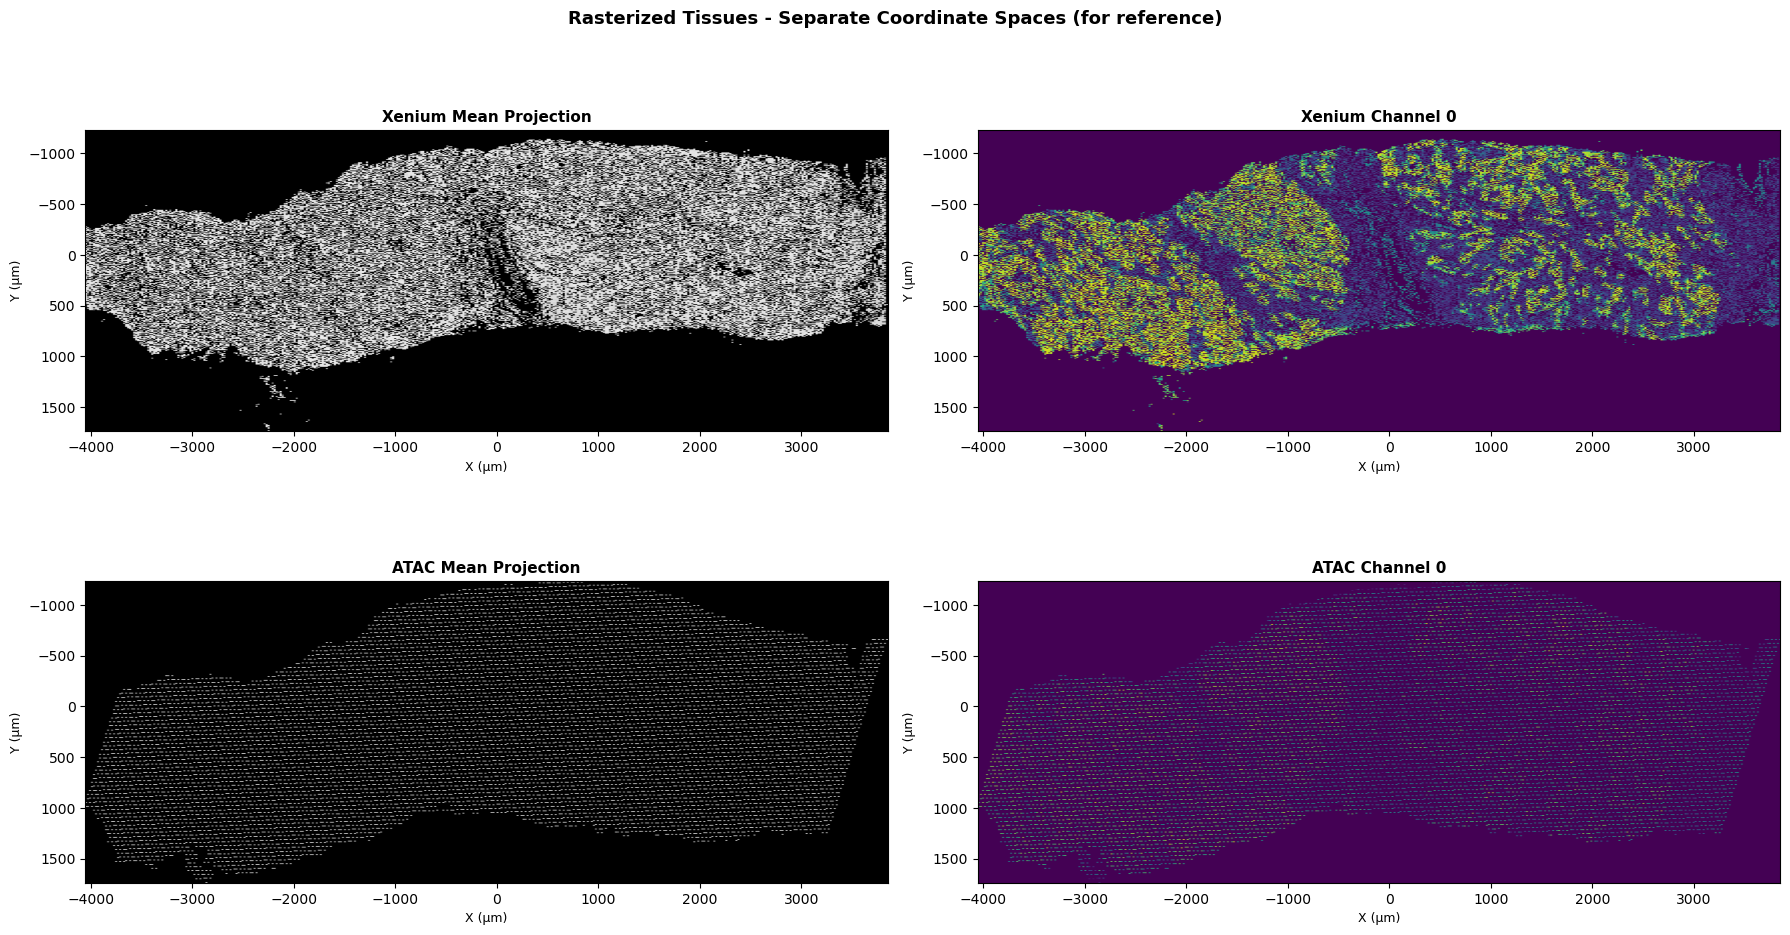


Rasterizing both tissues in ATAC's coordinate frame for overlay...
✓ Both tissues rasterized in same coordinate frame
Creating overlay composite (both in ATAC coordinate frame)...


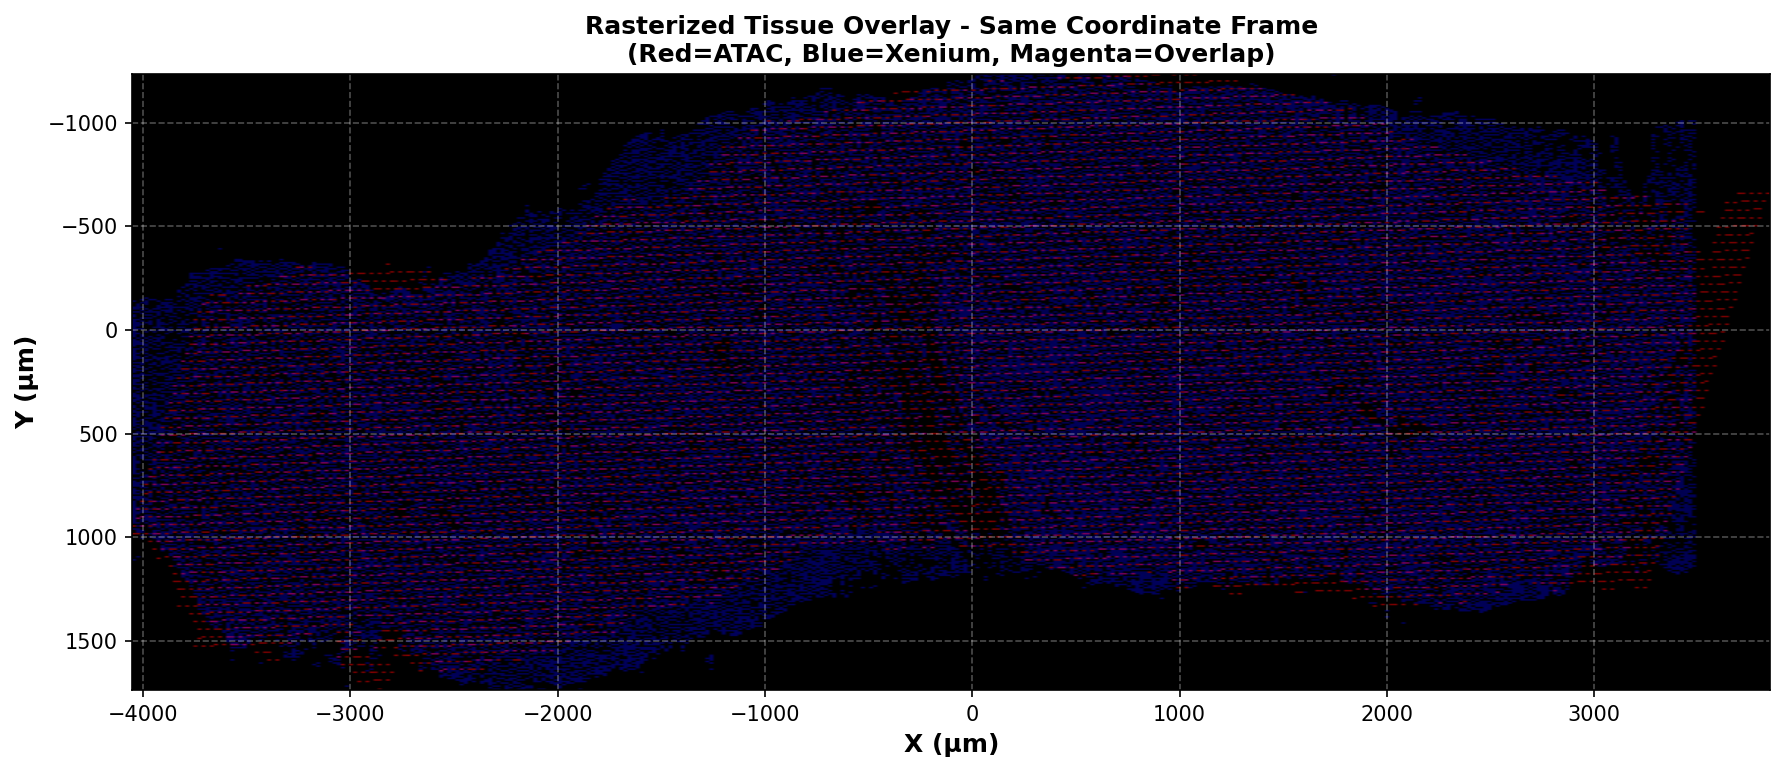

✓ Overlay complete (NO shift - both tissues in ATAC frame)
✓ Ready for nonlinear alignment


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
import anndata as ad
# Import MOSAICField functions (adjust as needed for your installation)
from src.MOSAICField.affine_alignment import affine_align
from src.MOSAICField.nonlinear_alignment import nonlinear_align

def rasterize_scaled(slice_adata, target_size=(400, 400), n_features=50):
    """
    Rasterizes spatial coordinates/features to a fixed-size grid using scaling.
    Returns: (img_uint8, (x_min, x_max, y_min, y_max)) - image and coordinate bounds
    """
    coords = np.asarray(slice_adata.obsm["spatial"], dtype=float)
    x, y = coords[:, 0], coords[:, 1]
    # Scale spatial coordinates to fill target grid
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    x_pix = ((x - x_min) / (x_max - x_min) * (target_size[1] - 1)).astype(int)
    y_pix = ((y - y_min) / (y_max - y_min) * (target_size[0] - 1)).astype(int)
    x_pix = np.clip(x_pix, 0, target_size[1] - 1)
    y_pix = np.clip(y_pix, 0, target_size[0] - 1)
    features = np.asarray(slice_adata.obsm['X_pca'])
    n_features = min(n_features, features.shape[1])
    img = np.zeros((target_size[0], target_size[1], n_features), dtype=np.float32)
    cnt = np.zeros((target_size[0], target_size[1]), dtype=np.int32)
    np.add.at(img, (y_pix, x_pix, slice(None)), features[:, :n_features])
    np.add.at(cnt, (y_pix, x_pix), 1)
    mask = cnt > 0
    img[mask] /= cnt[mask][..., None]
    img_uint8 = np.zeros_like(img, dtype=np.uint8)
    for c in range(n_features):
        ch = img[..., c]
        if np.any(mask):
            vmin, vmax = ch[mask].min(), ch[mask].max()
            if vmax > vmin:
                ch_norm = np.zeros_like(ch)
                ch_norm[mask] = (ch[mask] - vmin) / (vmax - vmin)
                img_uint8[..., c] = (ch_norm * 255).astype(np.uint8)
            else:
                img_uint8[..., c] = 0
        else:
            img_uint8[..., c] = 0
    return img_uint8, (x_min, x_max, y_min, y_max)

def rasterize_in_frame(slice_adata, frame_bounds, target_size=(400, 400), n_features=50):
    """
    Rasterizes into a FIXED frame (not auto-scaled to tissue bounds).
    Useful for overlaying multiple tissues in same coordinate space.
    """
    coords = np.asarray(slice_adata.obsm["spatial"], dtype=float)
    x, y = coords[:, 0], coords[:, 1]
    
    x_min, x_max, y_min, y_max = frame_bounds
    # Scale using frame bounds (not tissue bounds)
    x_pix = ((x - x_min) / (x_max - x_min) * (target_size[1] - 1)).astype(int)
    y_pix = ((y - y_min) / (y_max - y_min) * (target_size[0] - 1)).astype(int)
    
    # Clip to grid (cells outside frame are excluded)
    mask_in_frame = (x_pix >= 0) & (x_pix < target_size[1]) & (y_pix >= 0) & (y_pix < target_size[0])
    x_pix = x_pix[mask_in_frame]
    y_pix = y_pix[mask_in_frame]
    
    features = np.asarray(slice_adata.obsm['X_pca'])[mask_in_frame]
    n_features = min(n_features, features.shape[1])
    
    img = np.zeros((target_size[0], target_size[1], n_features), dtype=np.float32)
    cnt = np.zeros((target_size[0], target_size[1]), dtype=np.int32)
    np.add.at(img, (y_pix, x_pix, slice(None)), features[:, :n_features])
    np.add.at(cnt, (y_pix, x_pix), 1)
    
    mask = cnt > 0
    img[mask] /= cnt[mask][..., None]
    
    img_uint8 = np.zeros_like(img, dtype=np.uint8)
    for c in range(n_features):
        ch = img[..., c]
        if np.any(mask):
            vmin, vmax = ch[mask].min(), ch[mask].max()
            if vmax > vmin:
                ch_norm = np.zeros_like(ch)
                ch_norm[mask] = (ch[mask] - vmin) / (vmax - vmin)
                img_uint8[..., c] = (ch_norm * 255).astype(np.uint8)
            else:
                img_uint8[..., c] = 0
        else:
            img_uint8[..., c] = 0
    return img_uint8

# ======================
# Rasterize both tissues SEPARATELY (for reference)
# ======================
atac_affine_aligned = ad.read_h5ad(os.path.join(outdir, "atac_affine_aligned.h5ad"))
xenium_aligned = ad.read_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

print("Rasterizing affine-aligned tissues (separate coordinate frames for reference)...")
img_target_sep, bounds_target = rasterize_scaled(xenium_aligned, target_size=(400, 400), n_features=50)
img_source_sep, bounds_source = rasterize_scaled(atac_affine_aligned, target_size=(400, 400), n_features=50)

print(f"Rasterized target shape: {img_target_sep.shape}, source shape: {img_source_sep.shape}")
print(f"ATAC bounds: x=[{bounds_source[0]:.1f}, {bounds_source[1]:.1f}], y=[{bounds_source[2]:.1f}, {bounds_source[3]:.1f}]")
print(f"Xenium bounds: x=[{bounds_target[0]:.1f}, {bounds_target[1]:.1f}], y=[{bounds_target[2]:.1f}, {bounds_target[3]:.1f}]")

# Calculate COMBINED bounds to match scatter plot range
x_min_src, x_max_src, y_min_src, y_max_src = bounds_source
x_min_tgt, x_max_tgt, y_min_tgt, y_max_tgt = bounds_target

# Use combined bounds for all plots (match scatter plot auto-scale)
combined_x_min = min(x_min_src, x_min_tgt)
combined_x_max = max(x_max_src, x_max_tgt)
combined_y_min = min(y_min_src, y_min_tgt)
combined_y_max = max(y_max_src, y_max_tgt)

print(f"Combined bounds for all plots: x=[{combined_x_min:.1f}, {combined_x_max:.1f}], y=[{combined_y_min:.1f}, {combined_y_max:.1f}]")

# ======================
# Visualize rasterized tissues in SEPARATE COORDINATE SPACES (wider aspect ratio)
# ======================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Use COMBINED extent for all plots to match scatter plot
extent_all = [combined_x_min, combined_x_max, combined_y_max, combined_y_min]

axes[0, 0].imshow(img_target_sep.mean(axis=2), cmap='gray', extent=extent_all, aspect='equal', origin='upper')
axes[0, 0].set_title('Xenium Mean Projection', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('X (µm)', fontsize=9)
axes[0, 0].set_ylabel('Y (µm)', fontsize=9)

axes[0, 1].imshow(img_target_sep[..., 0], cmap='viridis', extent=extent_all, aspect='equal', origin='upper')
axes[0, 1].set_title('Xenium Channel 0', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('X (µm)', fontsize=9)
axes[0, 1].set_ylabel('Y (µm)', fontsize=9)

axes[1, 0].imshow(img_source_sep.mean(axis=2), cmap='gray', extent=extent_all, aspect='equal', origin='upper')
axes[1, 0].set_title('ATAC Mean Projection', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('X (µm)', fontsize=9)
axes[1, 0].set_ylabel('Y (µm)', fontsize=9)

axes[1, 1].imshow(img_source_sep[..., 0], cmap='viridis', extent=extent_all, aspect='equal', origin='upper')
axes[1, 1].set_title('ATAC Channel 0', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('X (µm)', fontsize=9)
axes[1, 1].set_ylabel('Y (µm)', fontsize=9)

plt.suptitle("Rasterized Tissues - Separate Coordinate Spaces (for reference)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ======================
# Now rasterize BOTH in ATAC's coordinate space for accurate overlay
# ======================
print("\nRasterizing both tissues in ATAC's coordinate frame for overlay...")
img_source_overlay = rasterize_in_frame(atac_affine_aligned, bounds_source, target_size=(400, 400), n_features=50)
img_target_overlay = rasterize_in_frame(xenium_aligned, bounds_source, target_size=(400, 400), n_features=50)
print("✓ Both tissues rasterized in same coordinate frame")

# ======================
# Create overlay visualization with NO SHIFT (both in ATAC frame)
# ======================
print("Creating overlay composite (both in ATAC coordinate frame)...")

# Normalize mean projections
mean_source_ov = img_source_overlay.mean(axis=2).astype(float) / 255.0
mean_target_ov = img_target_overlay.mean(axis=2).astype(float) / 255.0

# Create RGB composite: Red = ATAC, Blue = Xenium (BRIGHT RED)
composite = np.zeros((400, 400, 3), dtype=float)
composite[..., 0] = mean_source_ov          # Red channel = ATAC (full intensity)
composite[..., 2] = mean_target_ov * 0.7   # Blue channel = Xenium (slightly dimmed)
composite = np.clip(composite, 0, 1)

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
zoom_extent = [combined_x_min, combined_x_max, combined_y_max, combined_y_min]
im = ax.imshow(composite, extent=zoom_extent, aspect='equal', origin='upper')
ax.set_xlabel('X (µm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (µm)', fontsize=12, fontweight='bold')
ax.set_title('Rasterized Tissue Overlay - Same Coordinate Frame\n(Red=ATAC, Blue=Xenium, Magenta=Overlap)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', color='white')
plt.tight_layout()
plt.show()

print("✓ Overlay complete (NO shift - both tissues in ATAC frame)")


img_source = img_source_sep
img_target = img_target_sep

# Step 8: Full-Canvas Mapping & Final H5AD Outputs

**Dependencies**: Step 7e must complete first (creates phi field and displacement field).

This step:
1. Maps warped crop back to full tissue canvas
2. Uses phi field to transform ATAC cell coordinates to warped space  
3. Saves full-canvas images, arrays, and final h5ad objects with warped coordinates

**Outputs**:
- Full-canvas overlays (PNG)
- Array files: `img_source_full.npy`, `img_target_full.npy`, `warped_source_full.npy`
- Final h5ad objects: `atac_mosaicfield_final.h5ad`, `xenium_mosaicfield_final.h5ad`

In [15]:
### 7a. Define helper functions for preprocessing & visualization
import numpy as np
import torch
from scipy.ndimage import gaussian_filter

def robust_uint8_from_float(img_f, mask=None, qlo=1, qhi=99):
    """Convert float image to uint8 using robust quantile normalization"""
    out = np.zeros_like(img_f, dtype=np.uint8)
    if img_f.ndim == 2:
        arr = img_f[mask] if mask is not None else img_f.ravel()
        if arr.size == 0:
            return out
        lo, hi = np.percentile(arr, [qlo, qhi])
        if hi <= lo:
            return out
        z = np.clip((img_f - lo) / (hi - lo), 0, 1)
        return (z * 255).astype(np.uint8)

    H, W, C = img_f.shape
    for c in range(C):
        ch = img_f[..., c]
        arr = ch[mask] if mask is not None else ch.ravel()
        if arr.size == 0:
            continue
        lo, hi = np.percentile(arr, [qlo, qhi])
        if hi <= lo:
            continue
        z = np.clip((ch - lo) / (hi - lo), 0, 1)
        out[..., c] = (z * 255).astype(np.uint8)
    return out

def robust_float_vis(x, mask=None, qlo=1, qhi=99):
    """Convert to [0,1] float for visualization"""
    x = x.astype(np.float32)
    arr = x[mask] if mask is not None else x.ravel()
    if arr.size == 0:
        return np.zeros_like(x)
    lo, hi = np.percentile(arr, [qlo, qhi])
    if hi <= lo:
        return np.zeros_like(x)
    return np.clip((x - lo) / (hi - lo), 0, 1)

def get_tissue_mask(img_u8, min_signal=3):
    """Create binary mask of tissue (non-background)"""
    return img_u8.mean(axis=2) > min_signal

def bbox_from_mask(mask, pad=12):
    """Get bounding box from tissue mask with padding"""
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return 0, mask.shape[0], 0, mask.shape[1]
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    y0 = max(0, y0 - pad); y1 = min(mask.shape[0], y1 + pad)
    x0 = max(0, x0 - pad); x1 = min(mask.shape[1], x1 + pad)
    return y0, y1, x0, x1

def overlay_rgb(red_img, green_img):
    """Create RGB overlay (red + green channels)"""
    rgb = np.zeros((red_img.shape[0], red_img.shape[1], 3), dtype=np.uint8)
    rgb[..., 0] = red_img
    rgb[..., 1] = green_img
    return rgb

print("✓ Helper functions defined")

✓ Helper functions defined


In [28]:
### 7b. Preprocess: Crop & Blur Images

# Verify inputs exist
assert "img_source" in globals() and "img_target" in globals(), "Need img_source and img_target first."

# Create tissue masks
src_mask = get_tissue_mask(img_source, min_signal=3)
tgt_mask = get_tissue_mask(img_target, min_signal=3)
common_mask = src_mask | tgt_mask

# Get bounding box
y0, y1, x0, x1 = bbox_from_mask(common_mask, pad=12)
print(f"Crop box: y[{y0}:{y1}], x[{x0}:{x1}]")

# Crop images
img_source_crop = img_source[y0:y1, x0:x1, :].astype(np.float32)
img_target_crop = img_target[y0:y1, x0:x1, :].astype(np.float32)
print(f"Cropped shapes: {img_source_crop.shape}, {img_target_crop.shape}")

# Blur to reduce lattice artifacts
sigma_xy = 1.2
img_source_blur = gaussian_filter(img_source_crop, sigma=(sigma_xy, sigma_xy, 0))
img_target_blur = gaussian_filter(img_target_crop, sigma=(sigma_xy, sigma_xy, 0))

# Normalize to uint8
crop_mask = (img_target_crop.mean(axis=2) > 2) | (img_source_crop.mean(axis=2) > 2)
img_source_blur_u8 = robust_uint8_from_float(img_source_blur, mask=crop_mask)
img_target_blur_u8 = robust_uint8_from_float(img_target_blur, mask=crop_mask)

print("✓ Images cropped and blurred")

Crop box: y[0:400], x[0:400]
Cropped shapes: (400, 400, 50), (400, 400, 50)
✓ Images cropped and blurred


In [31]:
### 7c. Convert to Tensors & Configure Alignment Parameters

from types import SimpleNamespace
from src.MOSAICField.nonlinear_alignment import nonlinear_align

# Convert to PyTorch tensors (channels first)
source_t = torch.from_numpy(np.moveaxis(img_source_blur_u8, -1, 0)).float()  # [C, H, W]
target_t = torch.from_numpy(np.moveaxis(img_target_blur_u8, -1, 0)).float()

print(f"Input tensors:")
print(f"  source_t: {source_t.shape}")
print(f"  target_t: {target_t.shape}")

# Configure alignment hyperparameters
config = {
    "epoches": 1000,      # Training iterations
    "lr": 0.001,          # Learning rate
    "lambda_J": 2.5,      # Jacobian regularization weight
    "lambda_v": 1e-5,     # Displacement field smoothness weight
    "device": "cpu",      # Use CPU or GPU
}
config = SimpleNamespace(**config)

device = config.device
print(f"\n✓ Configuration ready (device={device})")
print(f"  Hyperparameters: {config.epoches} epochs, lr={config.lr}")

Input tensors:
  source_t: torch.Size([50, 400, 400])
  target_t: torch.Size([50, 400, 400])

✓ Configuration ready (device=cpu)
  Hyperparameters: 1000 epochs, lr=0.001


In [32]:
### 7d. Run Nonlinear Alignment (Neural Network Training)

print("\n" + "="*70)
print("Starting nonlinear alignment (this may take 2-5 minutes)...")
print("="*70)

# Run the alignment
warped_source_t, v, neuralnet = nonlinear_align(config, source_t, target_t)

# Convert back to numpy
warped_source = np.moveaxis(warped_source_t.detach().cpu().numpy(), 0, -1)  # [H, W, C]

print(f"\n✓ Alignment complete!")
print(f"  warped_source: {warped_source.shape}")
print(f"  displacement field v: shape={v.shape if hasattr(v, 'shape') else 'tensor'}")
print(f"  neuralnet: {type(neuralnet)}")


Starting nonlinear alignment (this may take 2-5 minutes)...
source.shape torch.Size([50, 400, 400])
target.shape torch.Size([50, 400, 400])
grid.shape torch.Size([2, 400, 400])
grid_batch.shape torch.Size([160000, 2])
scale_factor.shape torch.Size([2])
Total parameters: 8642
Iteration: 1 Loss: 6.863e-01
Iteration: 501 Loss: 3.802e-01

✓ Alignment complete!
  warped_source: (400, 400, 50)
  displacement field v: shape=torch.Size([1, 2, 400, 400])
  neuralnet: <class 'Network.DisplacementField'>



EXTRACTING COORDINATE MAPPING FIELD (phi)
✓ phi field extracted: shape=(1, 2, 400, 400) (1, 2, crop_h, crop_w)


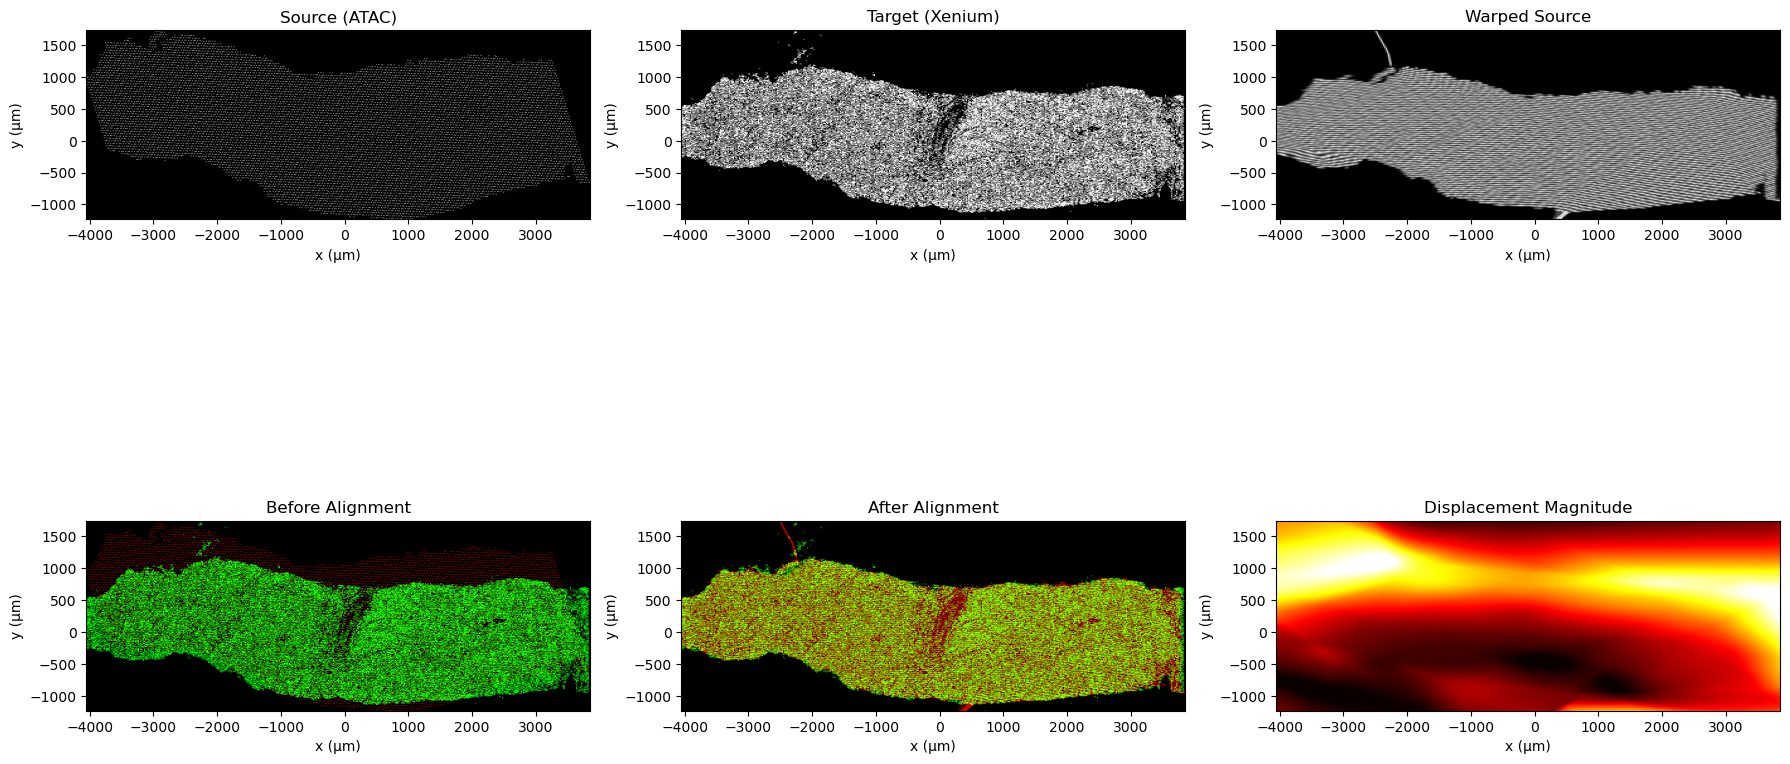


✓ Visualization saved to: ./mosaicfield_outputs/07e_alignment_results.png
✓ Saved phi coordinate mapping: ./mosaicfield_outputs/phi_coordinate_mapping.npy
  Shape: (1, 2, 400, 400), dtype: float32
✓ Saved displacement field v: ./mosaicfield_outputs/displacement_field_v.npy
  Shape: (1, 2, 400, 400), dtype: float32
✓ Saved metadata: ./mosaicfield_outputs/mapping_metadata.txt

✓ Step 7e complete!


In [33]:
### 7e. Visualize Alignment Results + Extract Coordinate Mapping

# Compute channel means for visualization (average across channel axis, axis 2)
src_mean = img_source_crop.mean(axis=2)
tgt_mean = img_target_crop.mean(axis=2)
war_mean = warped_source.mean(axis=2)

# Create crop_mask from the mean arrays themselves (ensures correct shape)
crop_mask = (tgt_mean > 2) | (src_mean > 2)

# Robust scaling to uint8
src_view = robust_uint8_from_float(src_mean, mask=crop_mask)
tgt_view = robust_uint8_from_float(tgt_mean, mask=crop_mask)
war_view = robust_uint8_from_float(war_mean, mask=crop_mask)

# Create overlays
ov_before = overlay_rgb(src_view, tgt_view)
ov_after = overlay_rgb(war_view, tgt_view)

# Compute deformation magnitude (mean across channels, axis 2)
disp_proxy = np.abs(warped_source.astype(np.float32) - img_source_blur_u8.astype(np.float32)).mean(axis=2)
mag_vis = robust_float_vis(disp_proxy, mask=crop_mask)

# Extract true displacement field magnitude
if isinstance(v, torch.Tensor):
    vv = v.detach().cpu().numpy()
    if vv.ndim == 4 and vv.shape[0] == 1:
        vv = vv[0]
    if vv.ndim == 3 and vv.shape[0] == 2:     # [2, H, W]
        mag = np.sqrt(vv[0]**2 + vv[1]**2)
        mag_vis = robust_float_vis(mag, mask=crop_mask)
    elif vv.ndim == 3 and vv.shape[-1] == 2:  # [H, W, 2]
        mag = np.sqrt(vv[..., 0]**2 + vv[..., 1]**2)
        mag_vis = robust_float_vis(mag, mask=crop_mask)

# ============================================================================
# EXTRACT COORDINATE MAPPING (Official MOSAICField approach)
# ============================================================================

print("\n" + "="*70)
print("EXTRACTING COORDINATE MAPPING FIELD (phi)")
print("="*70)

# Reverse warp to get coordinate mapping field phi
# phi[0, :, y, x] = where pixel (y,x) in source maps to in target space
back_warped_source_t, phi = warp_image_reverse(
    torch.from_numpy(warped_source).permute(2, 0, 1).unsqueeze(0), 
    v, 
    config.device
)

phi_numpy = phi.detach().cpu().numpy()  # Shape: [1, 2, H, W]
print(f"✓ phi field extracted: shape={phi_numpy.shape} (1, 2, crop_h, crop_w)")

# ============================================================================
# VISUALIZATIONS WITH COORDINATE AXES (matching rasterized style)
# ============================================================================

# Map crop box to real coordinates
x_min_crop = combined_x_min + (x0 / 400) * (combined_x_max - combined_x_min)
x_max_crop = combined_x_min + (x1 / 400) * (combined_x_max - combined_x_min)
y_min_crop = combined_y_min + (y0 / 400) * (combined_y_max - combined_y_min)
y_max_crop = combined_y_min + (y1 / 400) * (combined_y_max - combined_y_min)
extent_crop = [x_min_crop, x_max_crop, y_max_crop, y_min_crop]

# Create figure with coordinates
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

# Top row: individual mean projections
ax[0, 0].imshow(src_view, cmap='gray', extent=extent_crop, aspect='equal')
ax[0, 0].set_title('Source (ATAC)')
ax[0, 0].invert_yaxis()
ax[0, 0].set_xlabel('x (µm)')
ax[0, 0].set_ylabel('y (µm)')

ax[0, 1].imshow(tgt_view, cmap='gray', extent=extent_crop, aspect='equal')
ax[0, 1].set_title('Target (Xenium)')
ax[0, 1].invert_yaxis()
ax[0, 1].set_xlabel('x (µm)')
ax[0, 1].set_ylabel('y (µm)')

ax[0, 2].imshow(war_view, cmap='gray', extent=extent_crop, aspect='equal')
ax[0, 2].set_title('Warped Source')
ax[0, 2].invert_yaxis()
ax[0, 2].set_xlabel('x (µm)')
ax[0, 2].set_ylabel('y (µm)')

# Bottom row: overlays and displacement
ax[1, 0].imshow(ov_before, extent=extent_crop, aspect='equal')
ax[1, 0].set_title('Before Alignment')
ax[1, 0].invert_yaxis()
ax[1, 0].set_xlabel('x (µm)')
ax[1, 0].set_ylabel('y (µm)')

ax[1, 1].imshow(ov_after, extent=extent_crop, aspect='equal')
ax[1, 1].set_title('After Alignment')
ax[1, 1].invert_yaxis()
ax[1, 1].set_xlabel('x (µm)')
ax[1, 1].set_ylabel('y (µm)')

ax[1, 2].imshow(mag_vis, cmap='hot', extent=extent_crop, aspect='equal')
ax[1, 2].set_title('Displacement Magnitude')
ax[1, 2].invert_yaxis()
ax[1, 2].set_xlabel('x (µm)')
ax[1, 2].set_ylabel('y (µm)')

plt.tight_layout()
plt.savefig(os.path.join(outdir, "07e_alignment_results.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {outdir}/07e_alignment_results.png")

# ============================================================================
# SAVE COORDINATE MAPPING ARTIFACTS
# ============================================================================

# Save phi field (coordinate mapping)
phi_path = os.path.join(outdir, "phi_coordinate_mapping.npy")
np.save(phi_path, phi_numpy)
print(f"✓ Saved phi coordinate mapping: {phi_path}")
print(f"  Shape: {phi_numpy.shape}, dtype: {phi_numpy.dtype}")

# Save displacement field v for reference
v_numpy = v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else v
v_path = os.path.join(outdir, "displacement_field_v.npy")
np.save(v_path, v_numpy)
print(f"✓ Saved displacement field v: {v_path}")
print(f"  Shape: {v_numpy.shape}, dtype: {v_numpy.dtype}")

# Save metadata documentation
metadata_path = os.path.join(outdir, "mapping_metadata.txt")
with open(metadata_path, 'w') as f:
    f.write("COORDINATE MAPPING ARTIFACTS\n")
    f.write("="*70 + "\n\n")
    f.write(f"Generated: {pd.Timestamp.now()}\n\n")
    
    f.write("FILES:\n")
    f.write(f"  1. phi_coordinate_mapping.npy: {phi_numpy.shape} {phi_numpy.dtype}\n")
    f.write(f"     - Coordinate mapping field from warp_image_reverse()\n")
    f.write(f"     - phi[0, 0, y_pixel, x_pixel] = y_coordinate in target space\n")
    f.write(f"     - phi[0, 1, y_pixel, x_pixel] = x_coordinate in target space\n")
    f.write(f"     - Use this to warp arbitrary points/images\n\n")
    
    f.write(f"  2. displacement_field_v.npy: {v_numpy.shape} {v_numpy.dtype}\n")
    f.write(f"     - Raw displacement vectors from neural network\n")
    f.write(f"     - v[0, y, x] = y displacement\n")
    f.write(f"     - v[1, y, x] = x displacement\n\n")
    
    f.write("COORDINATE FRAMES:\n")
    f.write(f"  Crop region (pixels): y[{y0}:{y1}], x[{x0}:{x1}]\n")
    f.write(f"  Crop region (real):   x[{x_min_crop:.1f}, {x_max_crop:.1f}] µm\n")
    f.write(f"                        y[{y_min_crop:.1f}, {y_max_crop:.1f}] µm\n")
    f.write(f"  Combined frame:       x[{combined_x_min:.1f}, {combined_x_max:.1f}] µm\n")
    f.write(f"                        y[{combined_y_min:.1f}, {combined_y_max:.1f}] µm\n\n")
    
    f.write("USAGE:\n")
    f.write("  Load phi: phi = np.load('phi_coordinate_mapping.npy')\n")
    f.write("  Extract [2, H, W]: phi_field = phi[0] if phi.ndim == 4 else phi\n")
    f.write("  Apply to points: Use bilinear interpolation (RectBivariateSpline)\n")

print(f"✓ Saved metadata: {metadata_path}")
print(f"\n✓ Step 7e complete!")

## Step 8: Full-Canvas Mapping & Final H5AD Objects with Warped Coordinates

**Objectives**:
1. Map warped crop image back to full canvas
2. Transform ATAC cell coordinates to warped space using phi field
3. Create final h5ad objects with warped coordinates
4. Save full-canvas visualizations and arrays

**Inputs**:
- `warped_source_t`: Nonlinearly aligned image (from Step 7d)
- `img_source`, `img_target`: Full rasterized images (from Step 4)
- `phi`: Coordinate mapping field (from Step 7e)
- `atac_affine_aligned`: ATAC cells with affine coordinates (from earlier)

**Outputs**:
- `atac_mosaicfield_final.h5ad`: ATAC with `spatial_warped` in obsm
- `xenium_mosaicfield_final.h5ad`: Xenium with spatial coords
- Full-canvas overlay visualizations (PNG)
- Coordinate arrays (NPY files)


# Step 9: Xenium-to-ATAC Spot Mapping (Point-in-Polygon with Warped Coordinates)

**DEPENDENCY**: Must run Step 8 first. This step uses the warped ATAC coordinates from the nonlinear alignment.

Maps each Xenium cell to its containing ATAC 10µm square polygon **in the warped coordinate space**, using:
- Point-in-polygon containment check on warped ATAC spot locations (primary)


This produces biologically meaningful spot assignments because Xenium cells are matched to warped ATAC positions (after nonlinear alignment), not the original affine-aligned positions.

**Outputs**:
- `xenium_mosaicfield_final.h5ad` updated with `.obs['atac_spot_id_warped']` and `.obs['distance_to_atac_warped']`
- Mapping visualizations in warped coordinate space (PNG)

In [ ]:
# ============================================================================
# UPDATE H5AD OBJECTS WITH WARPED COORDINATES & SAVE
# ============================================================================

print("\n" + "="*70)
print("SAVING FINAL H5AD OBJECTS WITH WARPED COORDINATES")
print("="*70)

# Add coordinates to h5ad objects
import pandas as pd
atac_affine_aligned.obsm["spatial_warped"] = atac_coords_warped
atac_affine_aligned.obs["x_affine"] = atac_coords_affine[:, 0]
atac_affine_aligned.obs["y_affine"] = atac_coords_affine[:, 1]
atac_affine_aligned.obs["x_warped"] = atac_coords_warped[:, 0]
atac_affine_aligned.obs["y_warped"] = atac_coords_warped[:, 1]

xenium_aligned.obs["x"] = xenium_aligned.obsm["spatial"][:, 0]
xenium_aligned.obs["y"] = xenium_aligned.obsm["spatial"][:, 1]

# Store summary images in .uns for reference
atac_affine_aligned.uns["mosaicfield_summary"] = {
    "crop_box": {"y0": int(y0), "y1": int(y1), "x0": int(x0), "x1": int(x1)},
    "img_source_full_mean_u8": src_full_u8,
    "img_target_full_mean_u8": tgt_full_u8,
    "img_warped_full_mean_u8": wrp_full_u8,
}

# Save final h5ad objects
atac_h5ad_path = os.path.join(outdir, "atac_mosaicfield_final.h5ad")
xenium_h5ad_path = os.path.join(outdir, "xenium_mosaicfield_final.h5ad")

atac_affine_aligned.write_h5ad(atac_h5ad_path)
xenium_aligned.write_h5ad(xenium_h5ad_path)

print(f"✓ Saved final h5ad objects:")
print(f"  - {atac_h5ad_path}")
print(f"  - {xenium_h5ad_path}")

# Print summary
print(f"\n{'='*70}")
print("FINAL OUTPUT SUMMARY (Step 8)")
print(f"{'='*70}")
print(f"ATAC h5ad (.obsm):")
for key in atac_affine_aligned.obsm.keys():
    print(f"  - {key}: {atac_affine_aligned.obsm[key].shape}")
print(f"ATAC h5ad (.obs coordinate columns):")
for col in ['x_affine', 'y_affine', 'x_warped', 'y_warped']:
    if col in atac_affine_aligned.obs.columns:
        print(f"  - {col}")
print(f"\nXenium h5ad (.obs):")
print(f"  - x, y (spatial coordinates)")
print(f"\n✓ Step 8 complete!")


In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from types import SimpleNamespace
import anndata as ad

# ============================================================================
# SIMPLIFIED HELPER FUNCTIONS
# ============================================================================

def robust_normalize_uint8(img_f, mask=None, qlo=2, qhi=98):
    """Normalize float image to uint8 using quantiles"""
    if img_f.ndim == 2:
        img_f = img_f[..., np.newaxis]
    
    H, W, C = img_f.shape
    out = np.zeros((H, W, C), dtype=np.uint8)
    
    for c in range(C):
        ch = img_f[..., c]
        arr = ch[mask] if mask is not None else ch.ravel()
        if arr.size == 0:
            continue
        lo, hi = np.percentile(arr, [qlo, qhi])
        if hi > lo:
            z = np.clip((ch - lo) / (hi - lo), 0, 1)
            out[..., c] = (z * 255).astype(np.uint8)
    return out

def get_tissue_mask(img):
    """Binary mask where signal > threshold"""
    return img.mean(axis=2) > 2

def bbox_from_mask(mask, pad=12):
    """Get cropping box from mask"""
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return 0, mask.shape[0], 0, mask.shape[1]
    y0, y1 = max(0, ys.min() - pad), min(mask.shape[0], ys.max() + pad + 1)
    x0, x1 = max(0, xs.min() - pad), min(mask.shape[1], xs.max() + pad + 1)
    return y0, y1, x0, x1

# ============================================================================
# RASTERIZE WITH COORDINATE TRACKING
# ============================================================================

def rasterize_with_coords(adata, target_size=(400, 400), n_features=50):
    """
    Rasterize spatial data to grid, tracking original cell coordinates.
    
    Returns:
        dict with keys: 'img' (uint8 array), 'bounds' (x/y ranges), 
                       'cell_coords' (original coordinates), 'adata' (copy of input)
    """
    coords = np.asarray(adata.obsm["spatial"], dtype=float)
    x, y = coords[:, 0], coords[:, 1]
    
    # Scale to grid
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    x_pix = ((x - x_min) / (x_max - x_min) * (target_size[1] - 1)).astype(int)
    y_pix = ((y - y_min) / (y_max - y_min) * (target_size[0] - 1)).astype(int)
    x_pix = np.clip(x_pix, 0, target_size[1] - 1)
    y_pix = np.clip(y_pix, 0, target_size[0] - 1)
    
    # Aggregate features
    features = np.asarray(adata.obsm['X_pca'][:, :n_features])
    img = np.zeros((target_size[0], target_size[1], n_features), dtype=np.float32)
    cnt = np.zeros((target_size[0], target_size[1]), dtype=np.int32)
    np.add.at(img, (y_pix, x_pix, slice(None)), features)
    np.add.at(cnt, (y_pix, x_pix), 1)
    
    # Average
    mask = cnt > 0
    img[mask] /= cnt[mask][..., None]
    
    # Normalize to uint8
    img_uint8 = robust_normalize_uint8(img, mask=mask)
    
    return {
        'img': img_uint8,
        'bounds': (x_min, x_max, y_min, y_max),
        'cell_coords': coords,
        'adata': adata.copy(),
        'target_size': target_size
    }

# ============================================================================
# MAP COORDINATES THROUGH PHI (deformation field)
# ============================================================================

def map_coords_via_phi(source_result, phi):
    """
    Apply deformation field phi to source cell coordinates.
    
    Args:
        source_result: dict from rasterize_with_coords()
        phi: displacement field from neural network, shape (1, 2, H, W)
    
    Returns:
        mapped_coords: shape (N_cells, 2) with deformed coordinates
    """
    coords = source_result['cell_coords'].astype(float)
    x_min, x_max, y_min, y_max = source_result['bounds']
    H, W = source_result['target_size']
    
    x, y = coords[:, 0], coords[:, 1]
    
    # Convert to pixel coords
    x_pix = ((x - x_min) / (x_max - x_min) * (W - 1)).astype(int)
    y_pix = ((y - y_min) / (y_max - y_min) * (H - 1)).astype(int)
    x_pix = np.clip(x_pix, 0, W - 1)
    y_pix = np.clip(y_pix, 0, H - 1)
    
    # Get phi (convert from torch if needed)
    phi_np = phi.detach().cpu().numpy() if hasattr(phi, 'detach') else phi
    
    # Index phi: phi[batch=0, channels, y, x] -> (2, N)
    phi_mapped = phi_np[0, :, y_pix, x_pix]  # (2, N_cells)
    
    # Convert back to coordinates (phi is in pixel space, reverse x,y order)
    mapped_pixels = phi_mapped[[1, 0], :]  # Swap to (x, y)
    
    # Convert pixel displacement back to coordinate space
    mapped_coords = np.zeros_like(coords)
    mapped_coords[:, 0] = x_min + mapped_pixels[0, :] / (W - 1) * (x_max - x_min)
    mapped_coords[:, 1] = y_min + mapped_pixels[1, :] / (H - 1) * (y_max - y_min)
    
    return mapped_coords

# ============================================================================
# VISUALIZATION FUNCTIONS (from MOSAICField tutorial)
# ============================================================================

def visualize_slice(adata, title=""):
    """Plot cells colored by cluster"""
    coords = adata.obsm['spatial']
    clusters = adata.obs.get('cluster', adata.obs.get('Clusters', None))
    
    plt.figure(figsize=(8, 8))
    if clusters is not None:
        scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters.astype(int), 
                            s=1, alpha=0.6, cmap='tab20')
        plt.colorbar(scatter, label='Cluster')
    else:
        plt.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.6, c='blue')
    
    plt.gca().set_aspect('equal')
    plt.xlabel('X (µm)')
    plt.ylabel('Y (µm)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_slices_overlap(coord_list, titles=None, figsize=(14, 6)):
    """Overlay multiple coordinate sets"""
    if titles is None:
        titles = [f"Slice {i}" for i in range(len(coord_list))]
    
    colors = ['red', 'blue', 'green', 'yellow', 'cyan']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Separate
    for i, coords in enumerate(coord_list):
        ax1.scatter(coords[:, 0], coords[:, 1], s=2, alpha=0.5, 
                   label=titles[i], c=colors[i % len(colors)])
    ax1.set_aspect('equal')
    ax1.legend()
    ax1.set_title('Separate Coordinate Spaces')
    ax1.set_xlabel('X (µm)')
    ax1.set_ylabel('Y (µm)')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Overlay
    for i, coords in enumerate(coord_list):
        ax2.scatter(coords[:, 0], coords[:, 1], s=2, alpha=0.5, 
                   label=titles[i], c=colors[i % len(colors)])
    ax2.set_aspect('equal')
    ax2.legend()
    ax2.set_title('Overlay (Same Frame)')
    ax2.set_xlabel('X (µm)')
    ax2.set_ylabel('Y (µm)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✓ All functions defined")

# ============================================================================
# PREPROCESSING & ALIGNMENT (from your code)
# ============================================================================

# Crop & blur
src_mask = get_tissue_mask(img_source)
tgt_mask = get_tissue_mask(img_target)
y0, y1, x0, x1 = bbox_from_mask(src_mask | tgt_mask, pad=12)

img_source_crop = img_source[y0:y1, x0:x1, :].astype(np.float32)
img_target_crop = img_target[y0:y1, x0:x1, :].astype(np.float32)

img_source_blur = gaussian_filter(img_source_crop, sigma=(1.2, 1.2, 0))
img_target_blur = gaussian_filter(img_target_crop, sigma=(1.2, 1.2, 0))

img_source_blur_u8 = robust_normalize_uint8(img_source_blur)
img_target_blur_u8 = robust_normalize_uint8(img_target_blur)

print(f"✓ Preprocessing complete: {img_source_blur_u8.shape}, {img_target_blur_u8.shape}")

# Convert to torch
source_t = torch.from_numpy(np.moveaxis(img_source_blur_u8, -1, 0)).float()
target_t = torch.from_numpy(np.moveaxis(img_target_blur_u8, -1, 0)).float()

# Run alignment
config = SimpleNamespace(epoches=1000, lr=0.001, lambda_J=2.5, lambda_v=1e-5, device="cpu")
from src.MOSAICField.nonlinear_alignment import nonlinear_align

print("\nRunning nonlinear alignment...")
warped_source_t, v, neuralnet = nonlinear_align(config, source_t, target_t)
print("✓ Alignment complete")



✓ All functions defined
✓ Preprocessing complete: (400, 400, 50), (400, 400, 50)

Running nonlinear alignment...
source.shape torch.Size([50, 400, 400])
target.shape torch.Size([50, 400, 400])
grid.shape torch.Size([2, 400, 400])
grid_batch.shape torch.Size([160000, 2])
scale_factor.shape torch.Size([2])
Total parameters: 8642
Iteration: 1 Loss: 7.029e-01
Iteration: 501 Loss: 3.762e-01
✓ Alignment complete


NameError: name 'slice_source' is not defined

In [55]:
# ============================================================================
# LOAD ORIGINAL ANNDATA OBJECTS
# ============================================================================

# These should be your aligned AnnData files from MOSAICField
slice_source = ad.read_h5ad(os.path.join(outdir, "atac_affine_aligned.h5ad"))
slice_target = ad.read_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

print(f"Loaded source: {slice_source.shape}")
print(f"Loaded target: {slice_target.shape}")

# Verify they have spatial coords and PCA features
assert 'spatial' in slice_source.obsm, "Source needs obsm['spatial']"
assert 'X_pca' in slice_source.obsm, "Source needs obsm['X_pca']"
assert 'spatial' in slice_target.obsm, "Target needs obsm['spatial']"
assert 'X_pca' in slice_target.obsm, "Target needs obsm['X_pca']"

print("✓ Both tissues loaded with spatial and PCA data")

# ============================================================================
# RASTERIZE & MAP COORDINATES
# ============================================================================

# Rasterize both tissues
source_result = rasterize_with_coords(slice_source, target_size=(400, 400))
target_result = rasterize_with_coords(slice_target, target_size=(400, 400))

print(f"Source: {source_result['img'].shape}, {len(source_result['cell_coords'])} cells")
print(f"Target: {target_result['img'].shape}, {len(target_result['cell_coords'])} cells")

# Get phi from neural network and map source coordinates
phi = neuralnet(source_t.unsqueeze(0)).squeeze(0)  # (2, H, W)
phi = phi.unsqueeze(0)  # (1, 2, H, W) for indexing

sourcecoords_mapped = map_coords_via_phi(source_result, phi)
print(f"✓ Mapped coordinates shape: {sourcecoords_mapped.shape}")

# ============================================================================
# CREATE MAPPED ANNDATA & VISUALIZE
# ============================================================================

# Add mapped coordinates to AnnData
slice_source_mapped = source_result['adata'].copy()
slice_source_mapped.obsm['spatial_aligned'] = sourcecoords_mapped

# Visualize
print("\n" + "="*70)
print("VISUALIZATION")
print("="*70 + "\n")

print("1. Source tissue (original coordinates):")
visualize_slice(slice_source_mapped, "Source - Original")

print("2. Target tissue (original coordinates):")
visualize_slice(target_result['adata'], "Target")

print("3. Overlap comparison:")
plot_slices_overlap(
    [target_result['cell_coords'], sourcecoords_mapped],
    titles=['Target', 'Source (Aligned)']
)

print("\n✓ All visualizations complete!")

Loaded source: (11640, 2000)
Loaded target: (61151, 380)
✓ Both tissues loaded with spatial and PCA data
Source: (400, 400, 50), 11640 cells
Target: (400, 400, 50), 61151 cells


RuntimeError: mat1 and mat2 shapes cannot be multiplied (20000x400 and 2x64)


MAPPING COORDINATES (MOSAICField Tutorial Method)

Source: (400, 400, 50), 11640 cells
Target: (400, 400, 50), 61151 cells
✓ Mapped coordinates shape: (11640, 2)
  Original x range: [-3896.5, 3848.2]
  Mapped x range:   [-380.1, 888.1]
  Original y range: [-1115.6, 1130.3]
  Mapped y range:   [-146.0, 235.4]

VISUALIZATION

1. Source tissue (original coordinates):


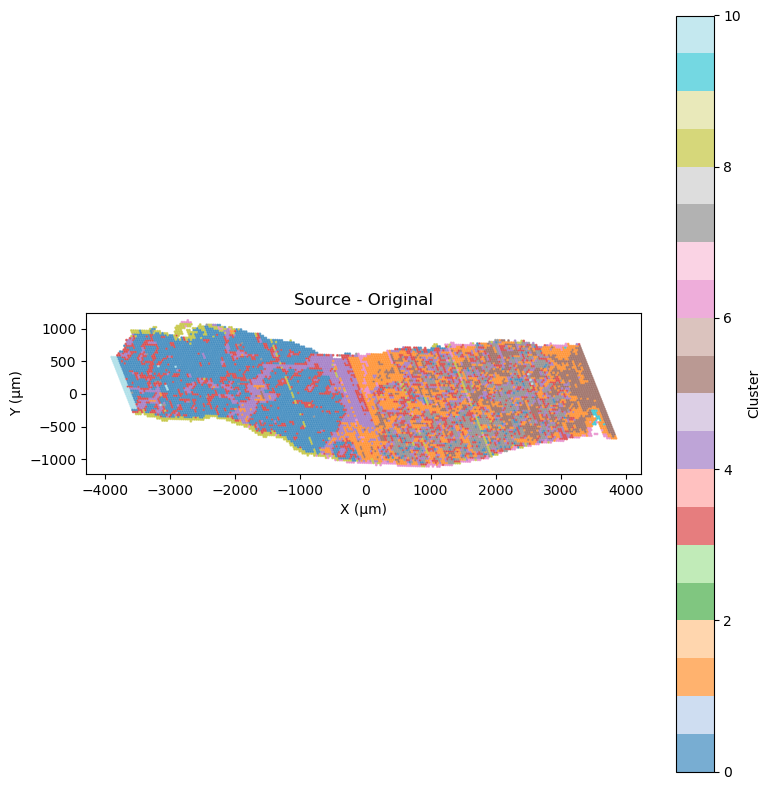

2. Target tissue (original coordinates):


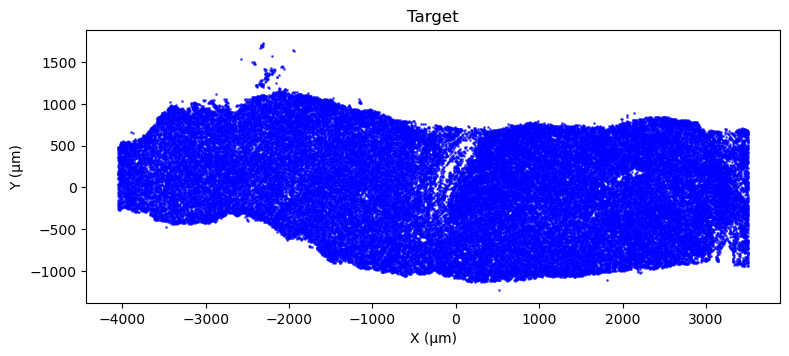

3. Overlap comparison:


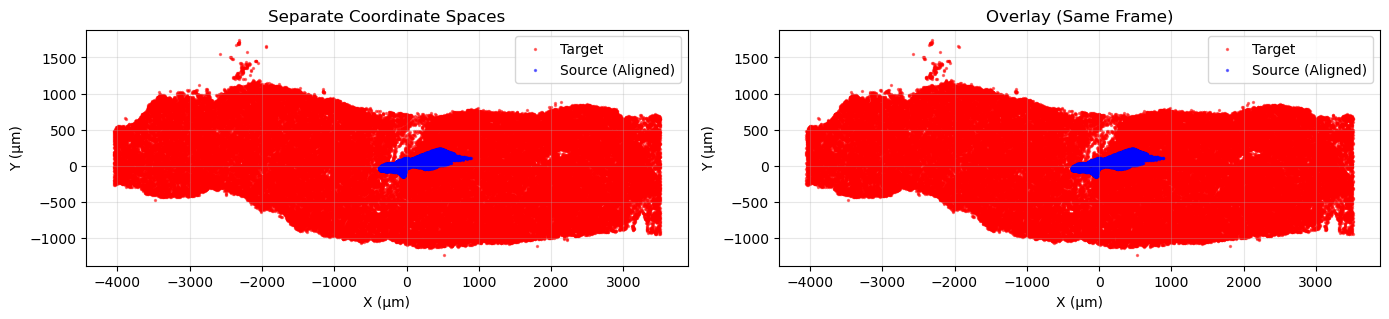


✓ Saved aligned source to source_aligned_final.h5ad


In [62]:
# ============================================================================
# MAP COORDINATES - FOLLOWING MOSAIC FIELD TUTORIAL
# ============================================================================

print("\n" + "="*70)
print("MAPPING COORDINATES (MOSAICField Tutorial Method)")
print("="*70 + "\n")

# Rasterize the original spatial data
source_result = rasterize_with_coords(slice_source, target_size=(400, 400), n_features=50)
target_result = rasterize_with_coords(slice_target, target_size=(400, 400), n_features=50)

print(f"Source: {source_result['img'].shape}, {len(source_result['cell_coords'])} cells")
print(f"Target: {target_result['img'].shape}, {len(target_result['cell_coords'])} cells")

# Get source coordinates (in pixel space, matching the 400x400 grid)
source_coords = source_result['cell_coords'].astype(float)
x_min, x_max, y_min, y_max = source_result['bounds']
H, W = source_result['target_size']

# Convert to pixel indices
x_pix = ((source_coords[:, 0] - x_min) / (x_max - x_min) * (W - 1)).astype(int)
y_pix = ((source_coords[:, 1] - y_min) / (y_max - y_min) * (H - 1)).astype(int)
x_pix = np.clip(x_pix, 0, W - 1)
y_pix = np.clip(y_pix, 0, H - 1)

# Get phi values at cell locations (directly from MOSAICField tutorial)
phi_np = phi.detach().cpu().numpy()
sourcecoords_mapped_norm = phi_np[0, :, y_pix, x_pix][:, ::-1]  # (N, 2) in normalized space

# Convert from normalized [-1, 1] space back to real coordinates
sourcecoords_mapped = np.zeros_like(source_coords)
sourcecoords_mapped[:, 0] = x_min + (sourcecoords_mapped_norm[:, 0] + 1) / 2 * (x_max - x_min)
sourcecoords_mapped[:, 1] = y_min + (sourcecoords_mapped_norm[:, 1] + 1) / 2 * (y_max - y_min)

print(f"✓ Mapped coordinates shape: {sourcecoords_mapped.shape}")
print(f"  Original x range: [{source_coords[:, 0].min():.1f}, {source_coords[:, 0].max():.1f}]")
print(f"  Mapped x range:   [{sourcecoords_mapped[:, 0].min():.1f}, {sourcecoords_mapped[:, 0].max():.1f}]")
print(f"  Original y range: [{source_coords[:, 1].min():.1f}, {source_coords[:, 1].max():.1f}]")
print(f"  Mapped y range:   [{sourcecoords_mapped[:, 1].min():.1f}, {sourcecoords_mapped[:, 1].max():.1f}]")

# ============================================================================
# VISUALIZE (MOSAICField Tutorial Method)
# ============================================================================

slice_source_mapped = source_result['adata'].copy()
slice_source_mapped.obsm['spatial_aligned'] = sourcecoords_mapped

print("\n" + "="*70)
print("VISUALIZATION")
print("="*70 + "\n")

print("1. Source tissue (original coordinates):")
visualize_slice(slice_source_mapped, "Source - Original")

print("2. Target tissue (original coordinates):")
visualize_slice(target_result['adata'], "Target")

print("3. Overlap comparison:")
plot_slices_overlap(
    [target_result['cell_coords'], sourcecoords_mapped],
    titles=['Target', 'Source (Aligned)']
)

# Save the mapped AnnData
slice_source_mapped.write_h5ad("source_aligned_final.h5ad")
print("\n✓ Saved aligned source to source_aligned_final.h5ad")

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from types import SimpleNamespace
import anndata as ad

from src.MOSAICField.nonlinear_alignment import nonlinear_align
# from src.MOSAICField.utils import warp_image_reverse

outdir = "./mosaicfield_outputs"
# ============================================================================
# STEP 1: LOAD AFFINE-ALIGNED OBJECTS (already in common frame)
# ============================================================================

print("="*70)
print("Loading affine-aligned data...")
print("="*70 + "\n")

# These should be from your affine alignment step
slice_source = ad.read_h5ad(os.path.join(outdir, "atac_affine_aligned.h5ad"))
slice_target = ad.read_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

print(f"Source: {slice_source.shape}")
print(f"Target: {slice_target.shape}")

# Get spatial coordinates
source_coords = slice_source.obsm['spatial'].astype(float)
target_coords = slice_target.obsm['spatial'].astype(float)

print(f"Source coords range: x=[{source_coords[:, 0].min():.1f}, {source_coords[:, 0].max():.1f}]")
print(f"Target coords range: x=[{target_coords[:, 0].min():.1f}, {target_coords[:, 0].max():.1f}]")

# ============================================================================
# STEP 2: RASTERIZE TO IMAGES (using PCA features)
# ============================================================================

def rasterize_simple(adata, target_size=(400, 400), n_features=50):
    """Rasterize PCA features to image"""
    coords = adata.obsm["spatial"].astype(float)
    x, y = coords[:, 0], coords[:, 1]
    
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    x_pix = ((x - x_min) / (x_max - x_min + 1e-8) * (target_size[1] - 1)).astype(int)
    y_pix = ((y - y_min) / (y_max - y_min + 1e-8) * (target_size[0] - 1)).astype(int)
    x_pix = np.clip(x_pix, 0, target_size[1] - 1)
    y_pix = np.clip(y_pix, 0, target_size[0] - 1)
    
    features = adata.obsm['X_pca'][:, :n_features].astype(np.float32)
    
    img = np.zeros((*target_size, n_features), dtype=np.float32)
    cnt = np.zeros(target_size, dtype=np.int32)
    np.add.at(img, (y_pix, x_pix, slice(None)), features)
    np.add.at(cnt, (y_pix, x_pix), 1)
    
    mask = cnt > 0
    img[mask] /= cnt[mask, np.newaxis]
    
    # Normalize to uint8
    img_uint8 = np.zeros_like(img, dtype=np.uint8)
    for c in range(n_features):
        ch = img[..., c]
        if np.any(mask):
            lo, hi = np.percentile(ch[mask], [2, 98])
            if hi > lo:
                img_uint8[..., c] = ((ch - lo) / (hi - lo) * 255).clip(0, 255).astype(np.uint8)
    
    return img_uint8, (x_min, x_max, y_min, y_max)

# Rasterize both
img_source, bounds_source = rasterize_simple(slice_source, target_size=(400, 400))
img_target, bounds_target = rasterize_simple(slice_target, target_size=(400, 400))

print(f"\nRasterized shapes: source={img_source.shape}, target={img_target.shape}")

# ============================================================================
# STEP 3: NONLINEAR ALIGNMENT (same as before)
# ============================================================================

# Convert to torch
source_t = torch.from_numpy(np.moveaxis(img_source, -1, 0)).float()
target_t = torch.from_numpy(np.moveaxis(img_target, -1, 0)).float()

config = SimpleNamespace(epoches=1000, lr=0.001, lambda_J=2.5, lambda_v=1e-5, device="cpu")

print("\nRunning nonlinear alignment...")
warped_source_t, v, neuralnet = nonlinear_align(config, source_t, target_t)
print("✓ Alignment complete")

# ============================================================================
# STEP 4: EXTRACT PHI AND MAP COORDINATES (MOSAICField tutorial method)
# ============================================================================

print("\n" + "="*70)
print("EXTRACTING AND APPLYING PHI")
print("="*70 + "\n")

# Get phi from network (like tutorial)
back_warped_source_t, phi = warp_image_reverse(
    warped_source_t.unsqueeze(0), 
    v, 
    config.device
)

phi_numpy = phi.detach().cpu().numpy()  # (1, 2, H, W)
print(f"Phi shape: {phi_numpy.shape}")

# ============================================================================
# MAP COORDINATES (MOSAICField tutorial exact method)
# ============================================================================

x_min_src, x_max_src, y_min_src, y_max_src = bounds_source
x_min_tgt, x_max_tgt, y_min_tgt, y_max_tgt = bounds_target

H, W = img_source.shape[:2]

# Convert source coordinates to pixel indices
x_pix = ((source_coords[:, 0] - x_min_src) / (x_max_src - x_min_src + 1e-8) * (W - 1)).astype(int)
y_pix = ((source_coords[:, 1] - y_min_src) / (y_max_src - y_min_src + 1e-8) * (H - 1)).astype(int)
x_pix = np.clip(x_pix, 0, W - 1)
y_pix = np.clip(y_pix, 0, H - 1)

# Get phi values at cell locations
phi_vals = phi_numpy[0, :, y_pix, x_pix]  # (2, N_cells) -> [dy, dx]

# Convert from pixel space to coordinate space
sourcecoords_mapped = np.zeros_like(source_coords)
sourcecoords_mapped[:, 0] = x_min_tgt + phi_vals[1, :] / (W - 1) * (x_max_tgt - x_min_tgt)  # x from phi[1]
sourcecoords_mapped[:, 1] = y_min_tgt + phi_vals[0, :] / (H - 1) * (y_max_tgt - y_min_tgt)  # y from phi[0]

print(f"✓ Mapped {len(sourcecoords_mapped)} cells")
print(f"  Source x: [{source_coords[:, 0].min():.1f}, {source_coords[:, 0].max():.1f}]")
print(f"  Mapped x: [{sourcecoords_mapped[:, 0].min():.1f}, {sourcecoords_mapped[:, 0].max():.1f}]")
print(f"  Target x: [{target_coords[:, 0].min():.1f}, {target_coords[:, 0].max():.1f}]")

# ============================================================================
# VISUALIZE
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Before
axes[0].scatter(source_coords[:, 0], source_coords[:, 1], s=2, alpha=0.6, c='red', label='Source')
axes[0].scatter(target_coords[:, 0], target_coords[:, 1], s=2, alpha=0.6, c='blue', label='Target')
axes[0].set_aspect('equal')
axes[0].set_title('Before Alignment')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After
axes[1].scatter(sourcecoords_mapped[:, 0], sourcecoords_mapped[:, 1], s=2, alpha=0.6, c='red', label='Source')
axes[1].scatter(target_coords[:, 0], target_coords[:, 1], s=2, alpha=0.6, c='blue', label='Target')
axes[1].set_aspect('equal')
axes[1].set_title('After Alignment')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Zoomed overlap
axes[2].scatter(target_coords[:, 0], target_coords[:, 1], s=2, alpha=0.4, c='blue', label='Target')
axes[2].scatter(sourcecoords_mapped[:, 0], sourcecoords_mapped[:, 1], s=2, alpha=0.4, c='red', label='Source')
axes[2].set_aspect('equal')
axes[2].set_title('Final Alignment')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("alignment_result.png", dpi=150)
plt.show()

# Save
slice_source_aligned = slice_source.copy()
slice_source_aligned.obsm['spatial_aligned'] = sourcecoords_mapped
slice_source_aligned.write_h5ad("source_aligned_final.h5ad")

print("\n✓ Complete! Saved: source_aligned_final.h5ad")

Loading affine-aligned data...

Source: (11640, 2000)
Target: (61151, 380)
Source coords range: x=[-3896.5, 3848.2]
Target coords range: x=[-4051.4, 3508.3]

Rasterized shapes: source=(400, 400, 50), target=(400, 400, 50)

Running nonlinear alignment...
source.shape torch.Size([50, 400, 400])
target.shape torch.Size([50, 400, 400])
grid.shape torch.Size([2, 400, 400])
grid_batch.shape torch.Size([160000, 2])
scale_factor.shape torch.Size([2])
Total parameters: 8642
Iteration: 1 Loss: 1.103e+00
Iteration: 501 Loss: 1.086e+00
✓ Alignment complete

EXTRACTING AND APPLYING PHI

Phi shape: (1, 2, 400, 400)


ValueError: could not broadcast input array from shape (2,) into shape (11640,)